In [34]:
from gerrychain import Graph
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain, proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.tree import recursive_tree_part, bipartition_tree, find_balanced_edge_cuts_memoization
from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias
from gerrychain.updaters import cut_edges

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [35]:
graph = Graph.from_json("./FL_Processed2/FL_Processed_Precincts_take2.json")
df = gpd.read_file("./FL_Processed2/FL_Processed_Precincts_take2.shp")

In [3]:
graph.edges["Monroe-:-5_0","Monroe-:-5_1"]['shared_perim'] = 0
graph.edges["Lee-:-516_0","Lee-:-516_1"]['shared_perim'] = 0
graph.edges["Lee-:-517_0","Lee-:-517_1"]['shared_perim'] = 0
graph.edges["Lee-:-513_0","Lee-:-513_1"]['shared_perim'] = 0
graph.edges["Lee-:-517_1","Lee-:-513_1"]['shared_perim'] = 0

In [48]:
df.keys()

Index(['NEW_PRECIN', 'population', 'populati_1', 'G24PRERTRU', 'G24PREDHAR',
       'G24USSDMUC', 'G24USSRSCO', 'Total', 'Hispanic', 'NH_White', 'NH_Black',
       'NH_Other', 'Total_VAP', 'Hispanic_V', 'NH_White_V', 'NH_Black_V',
       'NH_Other_V', 'COUNTYFP', 'CON22', 'CON26', 'SLDU', 'SLDL', 'C_X',
       'C_Y', 'geometry', 'current'],
      dtype='object')

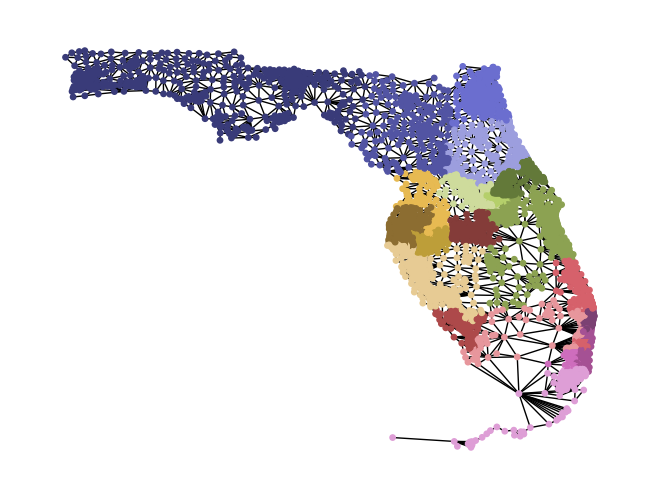

In [49]:
nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], 
graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[graph.nodes()[x]['CON26'] for x in graph.nodes()],cmap ='tab20b',node_size=15)

In [36]:
def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    df["current"] = df["NEW_PRECIN"].map(partition.assignment)

    counties = sum(df.groupby("COUNTYFP")['current'].nunique()>1)
    return counties

election_names = [
    "PRE",
    "USS"
]

num_elections = len(election_names)

election_columns = [
  ['G24PRERTRU','G24PREDHAR'],
  ['G24USSRSCO','G24USSDMUC']
]

my_updaters = {
    "population": updaters.Tally("population", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_NH_Black"] = graph.nodes()[node]["population"] - graph.nodes()[node]["NH_Black"]

my_updaters.update({"NH_Black":Election("NH_Black",{"NH_Black": "NH_Black", "non_NH_Black": "non_NH_Black"})})
my_updaters.update()

# save percentages

my_updaters.update(election_updaters)


In [5]:
ideal_population = df['population'].sum() / 28 # number of congressional districts
cd_dict = recursive_tree_part(graph, range(28), ideal_population, "population",.02)

In [37]:
tree_partition = GeographicPartition(graph, cd_dict, my_updaters)
CONPart = GeographicPartition(graph, "CON26", my_updaters)

In [40]:
(sorted(CONPart['PRE'].percents("Democratic")))

[0.3109543064911424,
 0.3472374964720538,
 0.3481464420261432,
 0.3716088631116955,
 0.3914502746076708,
 0.3916021930667062,
 0.39387929093480334,
 0.3988835964216274,
 0.40753140889814315,
 0.4109165244985153,
 0.41144848343406215,
 0.4140134837083189,
 0.4177868676705867,
 0.4180390504725004,
 0.42135540458111603,
 0.42243832595201253,
 0.427296450317553,
 0.42732592723950535,
 0.43268346353285564,
 0.43691280415708,
 0.44066293160140496,
 0.4480718194201004,
 0.4481216435075618,
 0.4561881709113871,
 0.569804437658005,
 0.6223113404697015,
 0.6930471344074398,
 0.6962679756840695]

In [7]:
print(sum([1/x for x in polsby_popper(CONPart).values()])/28)

print(mean_median(tree_partition["PRE"]))

print(CONPart["county_splits"])

3.419145068694334
-0.004815017293210266
23


In [8]:
def pp_constraint(partition):
    return sum([1/x for x in polsby_popper(partition).values()])/14 > 4

def county_constraint(partition):
    return partition['county_splits'] < 11

In [30]:
# proposal function
from functools import partial

proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    region_surcharge = {"COUNTYFP":0.64}, 
    method = partial(
        bipartition_tree,
        allow_pair_reselection=True,  
        max_attempts=100,
    ))

In [31]:
first_recom_chain = MarkovChain(
    proposal=proposal,
    constraints=[],
    accept=accept.always_accept,
    initial_state=CONPart,
    total_steps=5000
)

In [32]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins
ce = [] # cut edges

i = 0

for part in first_recom_chain: # num of trees to generate

    i += 1
    if i %500==0:
        print(i)
        print(sum(cs) / len(cs))

    cs.append(part['county_splits'])
    mms.append(mean_median(part['PRE']))
    egs.append(efficiency_gap(part['PRE']))
    pbs.append(partisan_bias(part['PRE']))
    dvp.append(sorted(part['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(part).values()])/28)
    bvp.append(sorted(part['NH_Black'].percents("NH_Black")))
    mbvp.append(max(bvp[-1]))
    wins.append(part['PRE'].wins("Democratic"))
    ce.append(len(part['cut_edges']))

    ad = dict(part.assignment)

"""
    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_Markov_gif_1/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(ad)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_Markov_gif_1/df_plot{i}.png')
    plt.close()
"""

500
23.17434869739479
1000
23.096096096096097
1500
22.657771847898598
2000
22.160580290145074
2500
22.2625050020008
3000
22.250083361120375
3500
22.416118891111747
4000
22.483620905226307
4500
22.57723938653034
5000
22.75375075015003


'\n    plt.figure(figsize=(10,4))\n    nx.draw(graph, pos={x:(graph.nodes()[x][\'C_X\'], graph.nodes()[x][\'C_Y\']) for x in graph.nodes()}, node_color=[ad[x] for x in graph.nodes()],cmap =\'tab20b\',node_size=15)\n    plt.savefig(f\'./NC_Markov_gif_1/network_plot_{i}.png\')\n    plt.close()\n\n    df[\'current\'] = df["PRECINCTID"].map(ad)\n    df.plot(column=\'current\',cmap=\'tab20b\')\n    plt.axis(\'off\')\n    plt.savefig(f\'./NC_Markov_gif_1/df_plot{i}.png\')\n    plt.close()\n'

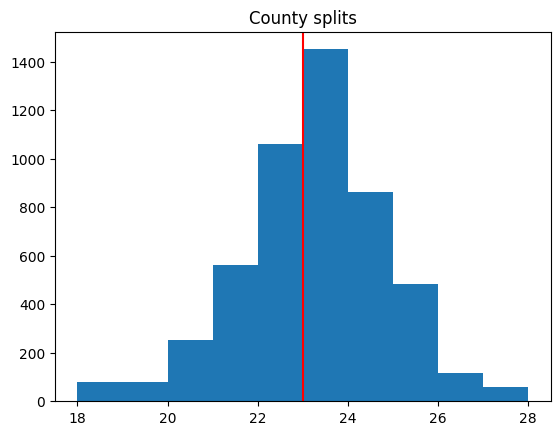

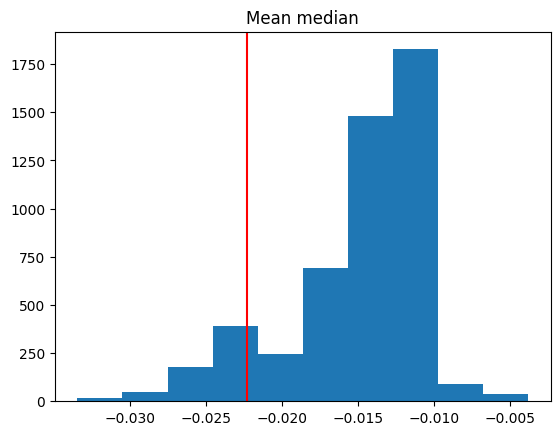

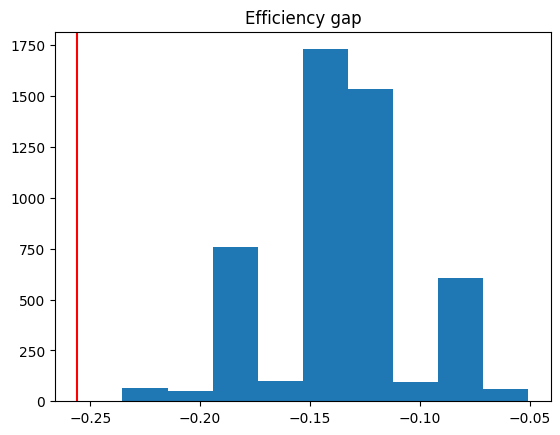

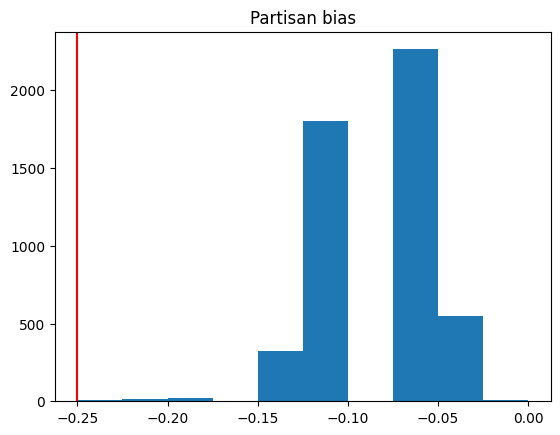

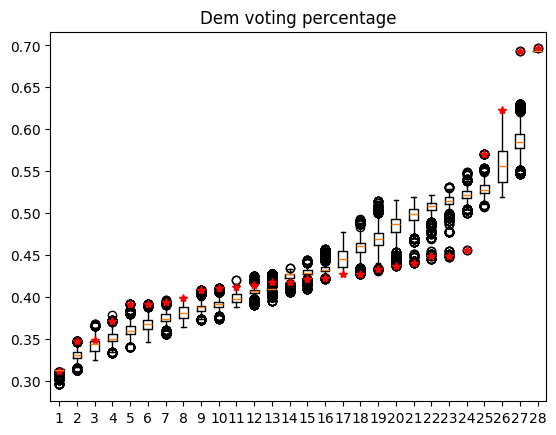

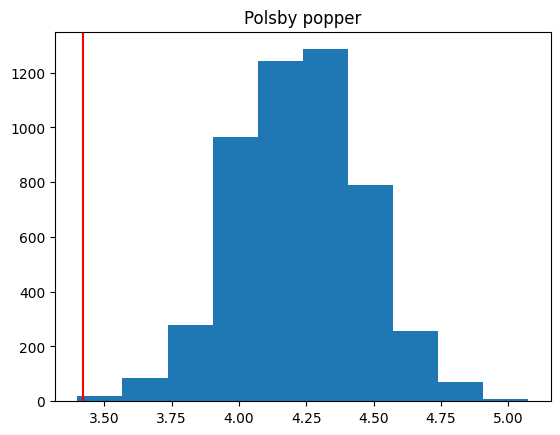

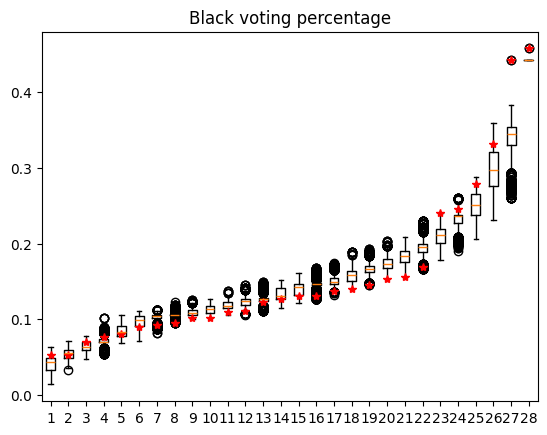

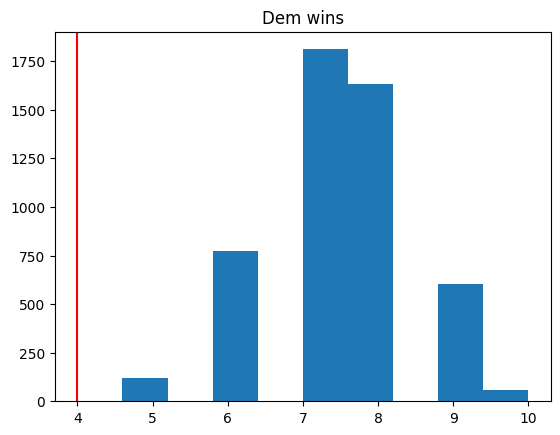

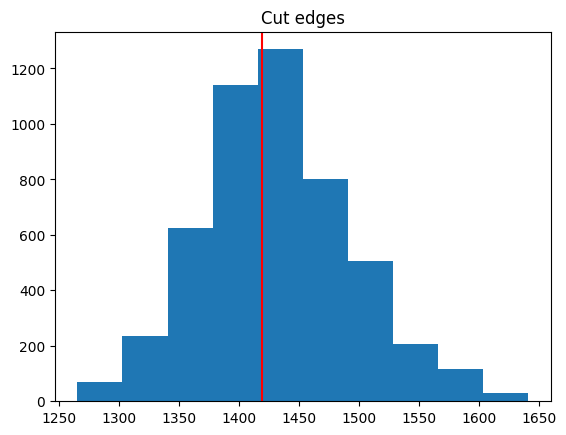

In [33]:
plt.hist(cs)
plt.axvline((CONPart['county_splits']), color='red',label='Enacted')
plt.title("County splits")
plt.show()

plt.hist(mms)
plt.axvline(mean_median(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Mean median")
plt.show()

plt.hist(egs)
plt.axvline(efficiency_gap(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Efficiency gap")
plt.show()

plt.hist(pbs)
plt.axvline(partisan_bias(CONPart["PRE"]), color='red',label='Enacted')
plt.title("Partisan bias")
plt.show()

dvp = np.array(dvp)
plt.boxplot(dvp)
plt.plot(range(1,29),(sorted(CONPart['PRE'].percents("Democratic"))), "*", color='red',label='Enacted')
plt.title("Dem voting percentage")
plt.show()

plt.hist(pps)
plt.axvline(sum([1/x for x in polsby_popper(CONPart).values()])/28, color='red',label='Enacted')
plt.title("Polsby popper")
plt.show()

bvp = np.array(bvp)
plt.boxplot(bvp)
plt.plot(range(1,29),(sorted(CONPart['NH_Black'].percents("NH_Black"))), "*", color='red',label='NH_Black')
plt.title("Black voting percentage")
plt.show()

plt.hist(wins)
plt.axvline(CONPart['PRE'].wins("Democratic"), color='red',label='Enacted')
plt.title("Dem wins")
plt.show()

plt.hist(ce)
plt.axvline(len(CONPart['cut_edges']), color='red',label='Enacted')
plt.title("Cut edges")
plt.show()